## 1. Configuración e Importaciones

In [1]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from pprint import pprint

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Métricas para multi-clase
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
np.random.seed(42)

import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Carga y Filtrado del Dataset

**Importante**: Solo usaremos emails con `label=1` (phishing) para clasificarlos por tipo.

In [2]:
# Cargar dataset completo
df_full = pd.read_csv("../Dataset/phishing_legit_dataset_KD_10000.csv", encoding="utf-8")

print("="*70)
print("DATASET COMPLETO")
print("="*70)
print(f"Total de muestras: {len(df_full):,}")
print(f"Distribución de label:")
print(df_full['label'].value_counts())

# Filtrar solo emails phishing (label=1)
df = df_full[df_full['label'] == 1].copy().reset_index(drop=True)

print("\n" + "="*70)
print("DATASET FILTRADO (SOLO PHISHING)")
print("="*70)
print(f"Total de emails phishing: {len(df):,}")
print(f"\nDistribución de tipos de phishing:")
print(df['phishing_type'].value_counts())

print(f"\nCantidad de clases: {df['phishing_type'].nunique()}")
print(f"Clases: {df['phishing_type'].unique()[:10]}...")  # Primeras 10

display(df.head(3))

DATASET COMPLETO
Total de muestras: 10,000
Distribución de label:
label
1    6000
0    4000
Name: count, dtype: int64

DATASET FILTRADO (SOLO PHISHING)
Total de emails phishing: 6,000

Distribución de tipos de phishing:
phishing_type
credential_harvesting          1000
urgency                        1000
financial_scam                  500
authority_scam                  500
romance_dating                  500
generic_phishing                500
threats                         500
tech_support                    500
social_engineering_advanced     500
social_engineering              500
Name: count, dtype: int64

Cantidad de clases: 10
Clases: ['credential_harvesting' 'financial_scam' 'authority_scam' 'urgency'
 'romance_dating' 'generic_phishing' 'threats' 'tech_support'
 'social_engineering_advanced' 'social_engineering']...


,text,label,phishing_type,severity,confidence
0,"Hello, your profile has been locked. Use the s...",1,credential_harvesting,high,0.89
1,"Hi there, congratulations! You are the winner ...",1,financial_scam,medium,0.69
2,"Attention, this is the fraud prevention accoun...",1,authority_scam,high,0.91


## 3. Análisis de Balance de Clases

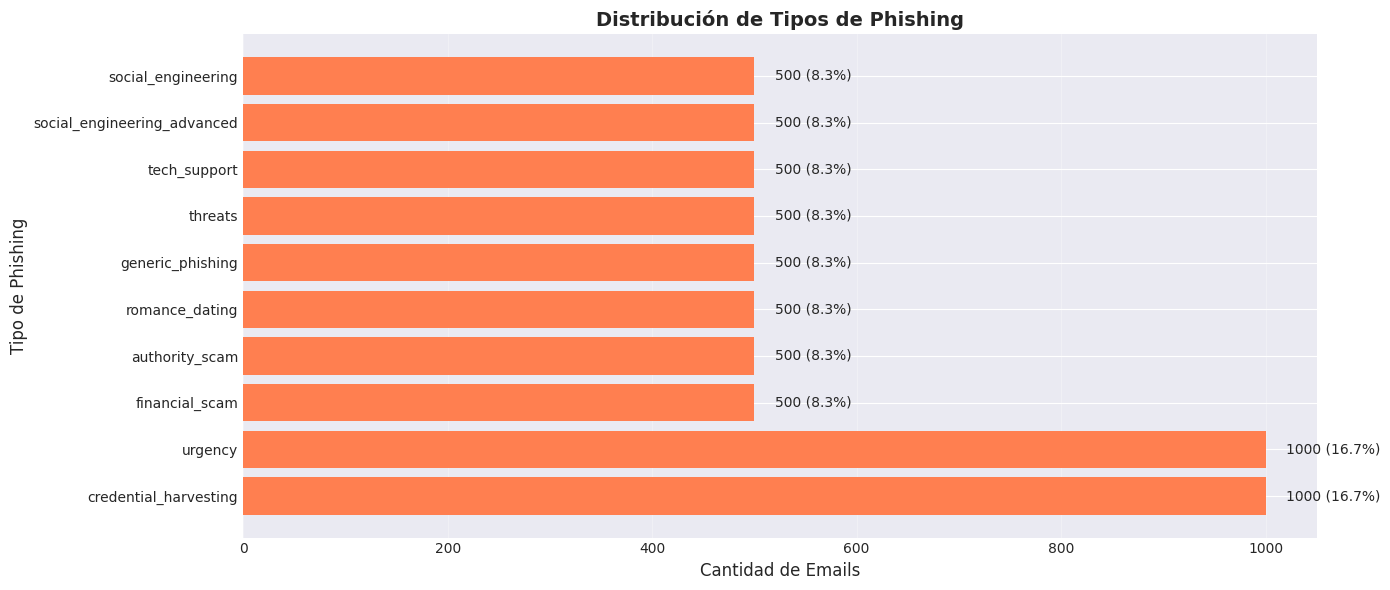


ANÁLISIS DE DESBALANCE
Clase más frecuente: credential_harvesting con 1000 muestras
Clase menos frecuente: financial_scam con 500 muestras
Ratio de desbalance: 2.00:1

✅ Dataset relativamente balanceado


In [3]:
# Visualizar distribución
plt.figure(figsize=(14, 6))

phishing_counts = df['phishing_type'].value_counts()

plt.barh(phishing_counts.index, phishing_counts.values, color='coral')
plt.xlabel('Cantidad de Emails', fontsize=12)
plt.ylabel('Tipo de Phishing', fontsize=12)
plt.title('Distribución de Tipos de Phishing', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Añadir valores
for i, (idx, value) in enumerate(phishing_counts.items()):
    plt.text(value + 20, i, f'{value} ({value/len(df)*100:.1f}%)', 
             va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Análisis de desbalance
print("\n" + "="*70)
print("ANÁLISIS DE DESBALANCE")
print("="*70)
max_class = phishing_counts.max()
min_class = phishing_counts.min()
ratio = max_class / min_class

print(f"Clase más frecuente: {phishing_counts.idxmax()} con {max_class} muestras")
print(f"Clase menos frecuente: {phishing_counts.idxmin()} con {min_class} muestras")
print(f"Ratio de desbalance: {ratio:.2f}:1")

if ratio > 3:
    print("\n⚠️ Dataset DESBALANCEADO - Considerar:")
    print("  - Usar 'balanced' class_weight en modelos")
    print("  - Evaluar con métricas por clase (precision/recall por tipo)")
    print("  - Considerar SMOTE o undersampling")
else:
    print("\n✅ Dataset relativamente balanceado")

## 4. Limpieza de Texto

In [4]:
def clean_text(text):
    """Limpia el texto de emails."""
    text = str(text).lower()
    
    # Remover línea de keywords (leakage)
    text = re.sub(r'keywords?:.*', '', text, flags=re.IGNORECASE)
    
    # Remover URLs y emails
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)
    
    # Remover números y puntuación
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remover espacios múltiples
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

print("🧹 Limpiando textos...")
df['text_clean'] = df['text'].apply(clean_text)
print(f"✅ Limpieza completada para {len(df):,} emails")

🧹 Limpiando textos...
✅ Limpieza completada para 6,000 emails


## 5. División de Datos

In [5]:
# Preparar datos
X = df['text_clean'].values
y = df['phishing_type'].values

# Codificar labels (convertir strings a números)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("="*70)
print("CODIFICACIÓN DE CLASES")
print("="*70)
print(f"Cantidad de clases: {len(label_encoder.classes_)}")
print(f"\nMapeo de clases:")
for idx, class_name in enumerate(label_encoder.classes_):
    print(f"  {idx}: {class_name}")

# División: 70% train, 15% val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_encoded, test_size=0.15, stratify=y_encoded, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42  # 0.176 * 0.85 ≈ 0.15
)

print("\n" + "="*70)
print("DIVISIÓN DE DATOS")
print("="*70)
print(f"Train:      {len(y_train):,} muestras ({len(y_train)/len(y_encoded)*100:.1f}%)")
print(f"Validation: {len(y_val):,} muestras ({len(y_val)/len(y_encoded)*100:.1f}%)")
print(f"Test:       {len(y_test):,} muestras ({len(y_test)/len(y_encoded)*100:.1f}%)")

print("\n✅ División completada con stratified sampling")

CODIFICACIÓN DE CLASES
Cantidad de clases: 10

Mapeo de clases:
  0: authority_scam
  1: credential_harvesting
  2: financial_scam
  3: generic_phishing
  4: romance_dating
  5: social_engineering
  6: social_engineering_advanced
  7: tech_support
  8: threats
  9: urgency

DIVISIÓN DE DATOS
Train:      4,202 muestras (70.0%)
Validation: 898 muestras (15.0%)
Test:       900 muestras (15.0%)

✅ División completada con stratified sampling


## 6. Modelo 1: Random Forest

In [6]:
print("="*70)
print("MODELO 1: RANDOM FOREST")
print("="*70)

# Pipeline
pipeline_rf = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=3000,
        ngram_range=(1, 2),
        max_df=0.85,
        min_df=3,
        stop_words='english',
        sublinear_tf=True
    )),
    ('clf', RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'  # Importante para clases desbalanceadas
    ))
])

# Grid de hiperparámetros
param_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [20, 30],
    'clf__min_samples_split': [5, 10]
}

print("🔍 Optimizando hiperparámetros...")

grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid_rf,
    cv=3,
    scoring='f1_macro',  # F1 promedio entre todas las clases
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("\n" + "="*70)
print("MEJORES HIPERPARÁMETROS")
print("="*70)
pprint(grid_rf.best_params_)
print(f"\nMejor F1-Macro (CV): {grid_rf.best_score_:.4f}")

model_rf = grid_rf.best_estimator_

MODELO 1: RANDOM FOREST
🔍 Optimizando hiperparámetros...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

MEJORES HIPERPARÁMETROS
{'clf__max_depth': 20, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}

Mejor F1-Macro (CV): 1.0000


### 6.1 Evaluación Random Forest

In [7]:
# Predicciones
y_train_pred_rf = model_rf.predict(X_train)
y_val_pred_rf = model_rf.predict(X_val)
y_test_pred_rf = model_rf.predict(X_test)

# Métricas
print("="*70)
print("MÉTRICAS - RANDOM FOREST")
print("="*70)

for name, y_true, y_pred in [('Train', y_train, y_train_pred_rf),
                              ('Validation', y_val, y_val_pred_rf),
                              ('Test', y_test, y_test_pred_rf)]:
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\n{name}:")
    print(f"  Accuracy:    {acc:.4f}")
    print(f"  F1-Macro:    {f1_macro:.4f}  (promedio simple entre clases)")
    print(f"  F1-Weighted: {f1_weighted:.4f}  (ponderado por soporte)")

# Reporte de clasificación detallado
print("\n" + "="*70)
print("REPORTE DETALLADO POR CLASE (TEST SET)")
print("="*70)
print(classification_report(
    y_test, 
    y_test_pred_rf, 
    target_names=label_encoder.classes_,
    digits=4
))

MÉTRICAS - RANDOM FOREST

Train:
  Accuracy:    1.0000
  F1-Macro:    1.0000  (promedio simple entre clases)
  F1-Weighted: 1.0000  (ponderado por soporte)

Validation:
  Accuracy:    1.0000
  F1-Macro:    1.0000  (promedio simple entre clases)
  F1-Weighted: 1.0000  (ponderado por soporte)

Test:
  Accuracy:    1.0000
  F1-Macro:    1.0000  (promedio simple entre clases)
  F1-Weighted: 1.0000  (ponderado por soporte)

REPORTE DETALLADO POR CLASE (TEST SET)
                             precision    recall  f1-score   support

             authority_scam     1.0000    1.0000    1.0000        75
      credential_harvesting     1.0000    1.0000    1.0000       150
             financial_scam     1.0000    1.0000    1.0000        75
           generic_phishing     1.0000    1.0000    1.0000        75
             romance_dating     1.0000    1.0000    1.0000        75
         social_engineering     1.0000    1.0000    1.0000        75
social_engineering_advanced     1.0000    1.0000    1.

### 6.2 Matriz de Confusión Multi-Clase

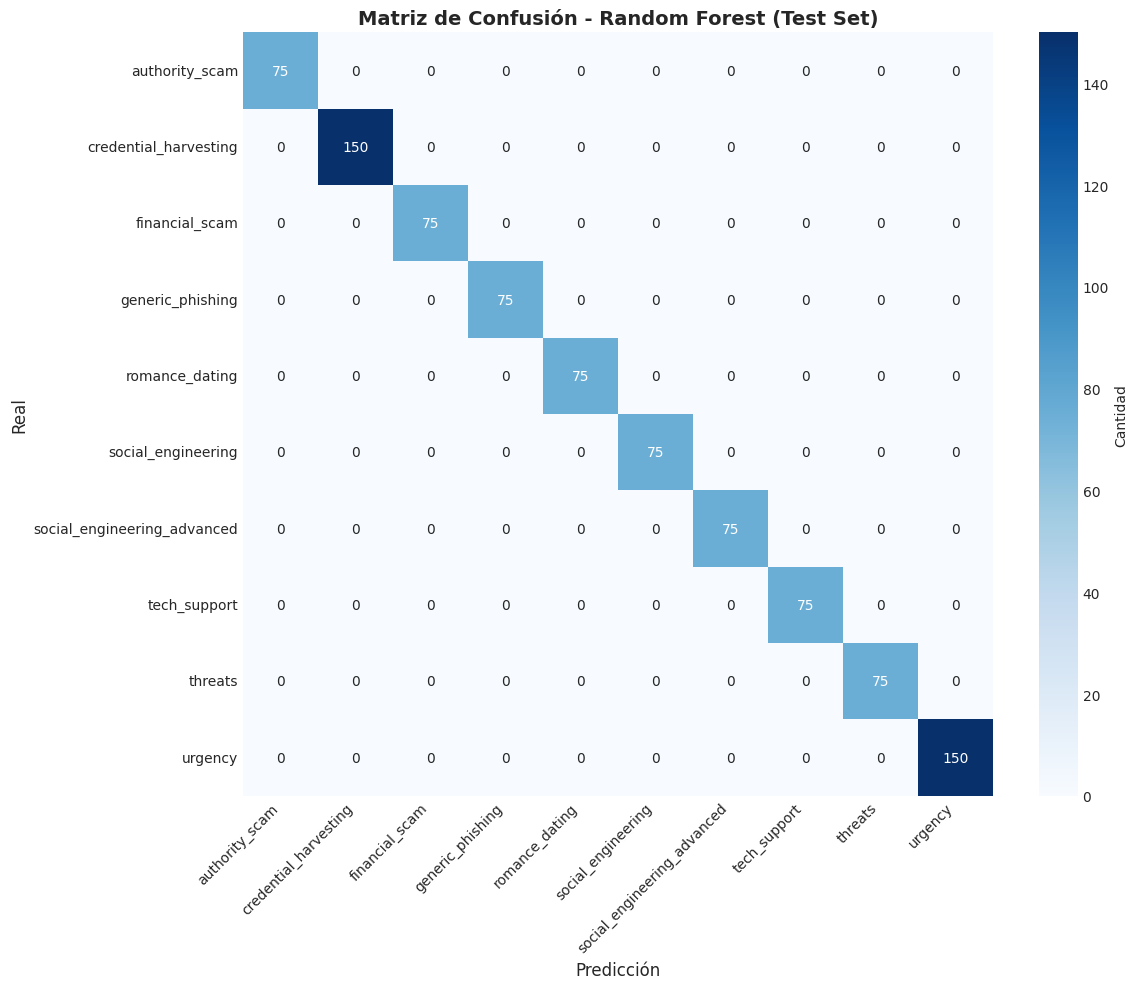


CONFUSIONES MÁS COMUNES (errores fuera de diagonal)


KeyError: 'Cantidad'

In [8]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred_rf)

# Visualizar
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_,
            cbar_kws={'label': 'Cantidad'})
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)
plt.title('Matriz de Confusión - Random Forest (Test Set)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Análisis de confusiones más comunes
print("\n" + "="*70)
print("CONFUSIONES MÁS COMUNES (errores fuera de diagonal)")
print("="*70)

# Crear lista de confusiones
confusions = []
for i in range(len(cm)):
    for j in range(len(cm)):
        if i != j and cm[i, j] > 0:
            confusions.append({
                'Real': label_encoder.classes_[i],
                'Predicho': label_encoder.classes_[j],
                'Cantidad': cm[i, j]
            })

confusions_df = pd.DataFrame(confusions).sort_values('Cantidad', ascending=False)
display(confusions_df.head(10))

## 7. Modelo 2: Gradient Boosting

In [9]:
print("="*70)
print("MODELO 2: GRADIENT BOOSTING")
print("="*70)

# Pipeline
pipeline_gb = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=3000,
        ngram_range=(1, 2),
        max_df=0.85,
        min_df=3,
        stop_words='english',
        sublinear_tf=True
    )),
    ('clf', GradientBoostingClassifier(
        random_state=42,
        n_estimators=100
    ))
])

# Grid reducido (Gradient Boosting es más lento)
param_grid_gb = {
    'clf__learning_rate': [0.05, 0.1],
    'clf__max_depth': [3, 5],
    'clf__n_estimators': [100, 150]
}

print("🔍 Optimizando hiperparámetros...")
print("⚠️ Este proceso puede tomar varios minutos...")

grid_gb = GridSearchCV(
    pipeline_gb,
    param_grid_gb,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_gb.fit(X_train, y_train)

print("\n" + "="*70)
print("MEJORES HIPERPARÁMETROS")
print("="*70)
pprint(grid_gb.best_params_)
print(f"\nMejor F1-Macro (CV): {grid_gb.best_score_:.4f}")

model_gb = grid_gb.best_estimator_

# Evaluar
y_test_pred_gb = model_gb.predict(X_test)

print("\n" + "="*70)
print("MÉTRICAS EN TEST SET")
print("="*70)
acc_gb = accuracy_score(y_test, y_test_pred_gb)
f1_macro_gb = f1_score(y_test, y_test_pred_gb, average='macro')
f1_weighted_gb = f1_score(y_test, y_test_pred_gb, average='weighted')

print(f"Accuracy:    {acc_gb:.4f}")
print(f"F1-Macro:    {f1_macro_gb:.4f}")
print(f"F1-Weighted: {f1_weighted_gb:.4f}")

MODELO 2: GRADIENT BOOSTING
🔍 Optimizando hiperparámetros...
⚠️ Este proceso puede tomar varios minutos...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

MEJORES HIPERPARÁMETROS
{'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__n_estimators': 100}

Mejor F1-Macro (CV): 1.0000

MÉTRICAS EN TEST SET
Accuracy:    1.0000
F1-Macro:    1.0000
F1-Weighted: 1.0000


## 8. Modelo 3: Logistic Regression Multinomial

In [10]:
print("="*70)
print("MODELO 3: LOGISTIC REGRESSION MULTINOMIAL")
print("="*70)

# Pipeline
pipeline_lr = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=3000,
        ngram_range=(1, 2),
        max_df=0.85,
        min_df=3,
        stop_words='english',
        sublinear_tf=True
    )),
    ('clf', LogisticRegression(
        multi_class='multinomial',
        solver='saga',
        max_iter=1000,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

# Grid
param_grid_lr = {
    'clf__C': [0.1, 1.0, 10.0],
    'clf__penalty': ['l2']
}

print("🔍 Optimizando hiperparámetros...")

grid_lr = GridSearchCV(
    pipeline_lr,
    param_grid_lr,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)

print("\n" + "="*70)
print("MEJORES HIPERPARÁMETROS")
print("="*70)
pprint(grid_lr.best_params_)
print(f"\nMejor F1-Macro (CV): {grid_lr.best_score_:.4f}")

model_lr = grid_lr.best_estimator_

# Evaluar
y_test_pred_lr = model_lr.predict(X_test)

print("\n" + "="*70)
print("MÉTRICAS EN TEST SET")
print("="*70)
acc_lr = accuracy_score(y_test, y_test_pred_lr)
f1_macro_lr = f1_score(y_test, y_test_pred_lr, average='macro')
f1_weighted_lr = f1_score(y_test, y_test_pred_lr, average='weighted')

print(f"Accuracy:    {acc_lr:.4f}")
print(f"F1-Macro:    {f1_macro_lr:.4f}")
print(f"F1-Weighted: {f1_weighted_lr:.4f}")

MODELO 3: LOGISTIC REGRESSION MULTINOMIAL
🔍 Optimizando hiperparámetros...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

MEJORES HIPERPARÁMETROS
{'clf__C': 0.1, 'clf__penalty': 'l2'}

Mejor F1-Macro (CV): 1.0000

MÉTRICAS EN TEST SET
Accuracy:    1.0000
F1-Macro:    1.0000
F1-Weighted: 1.0000


## 9. Comparación Final

COMPARACIÓN FINAL DE MODELOS (TEST SET)


,accuracy,f1_macro,f1_weighted
Random Forest,1.0,1.0,1.0
Gradient Boosting,1.0,1.0,1.0
Logistic Regression,1.0,1.0,1.0


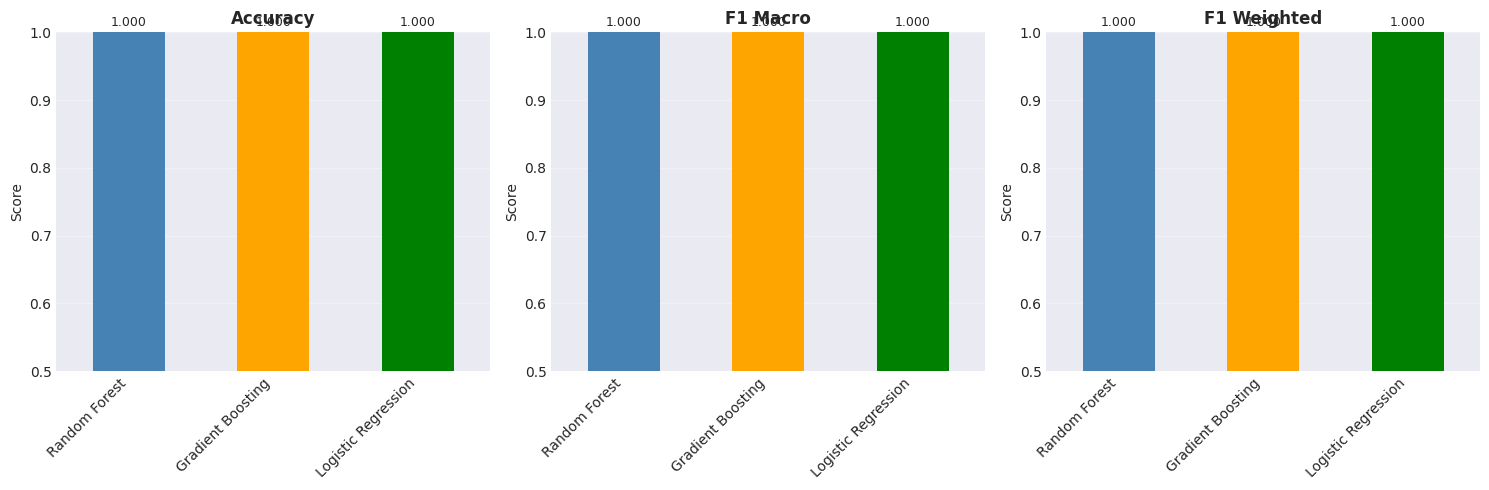


🏆 MEJOR MODELO
Modelo: Random Forest
F1-Macro: 1.0000


In [11]:
# Compilar resultados
comparison = pd.DataFrame({
    'Random Forest': {
        'accuracy': accuracy_score(y_test, y_test_pred_rf),
        'f1_macro': f1_score(y_test, y_test_pred_rf, average='macro'),
        'f1_weighted': f1_score(y_test, y_test_pred_rf, average='weighted')
    },
    'Gradient Boosting': {
        'accuracy': acc_gb,
        'f1_macro': f1_macro_gb,
        'f1_weighted': f1_weighted_gb
    },
    'Logistic Regression': {
        'accuracy': acc_lr,
        'f1_macro': f1_macro_lr,
        'f1_weighted': f1_weighted_lr
    }
}).T

print("="*70)
print("COMPARACIÓN FINAL DE MODELOS (TEST SET)")
print("="*70)
display(comparison.round(4))

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, metric in enumerate(['accuracy', 'f1_macro', 'f1_weighted']):
    comparison[metric].plot(kind='bar', ax=axes[idx], 
                            color=['steelblue', 'orange', 'green'])
    axes[idx].set_title(metric.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Score')
    axes[idx].set_ylim([0.5, 1.0])
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].set_xticklabels(comparison.index, rotation=45, ha='right')
    
    # Valores
    for i, v in enumerate(comparison[metric]):
        axes[idx].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Mejor modelo
best_model_name = comparison['f1_macro'].idxmax()
best_f1 = comparison['f1_macro'].max()

print("\n" + "="*70)
print("🏆 MEJOR MODELO")
print("="*70)
print(f"Modelo: {best_model_name}")
print(f"F1-Macro: {best_f1:.4f}")

## 10. Análisis de Features Importantes (Random Forest)

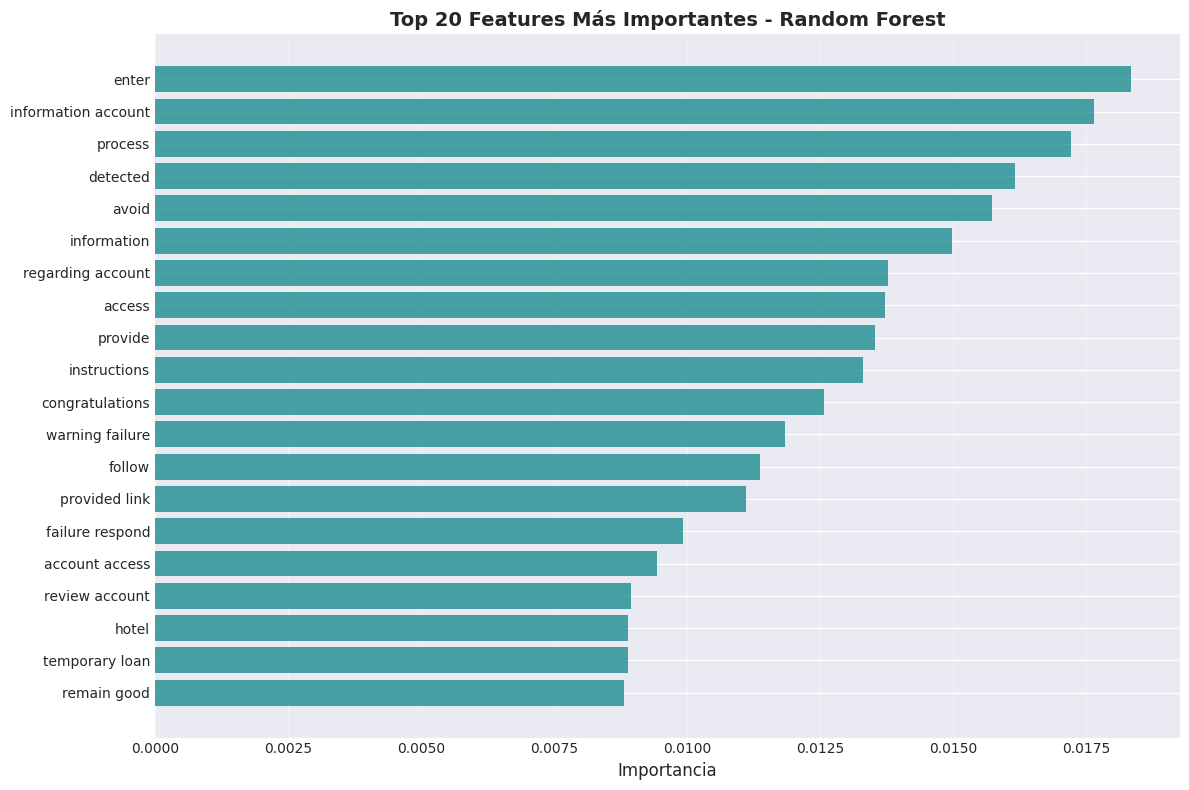


📊 Estas palabras/bigramas son las más importantes para distinguir tipos de phishing


In [12]:
# Obtener importancia de features del Random Forest
tfidf_vectorizer = model_rf.named_steps['tfidf']
clf_rf = model_rf.named_steps['clf']

feature_names = tfidf_vectorizer.get_feature_names_out()
importances = clf_rf.feature_importances_

# Crear DataFrame
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Top 20 features
top_features = feature_importance.head(20)

# Visualizar
plt.figure(figsize=(12, 8))
plt.barh(top_features['feature'], top_features['importance'], color='teal', alpha=0.7)
plt.xlabel('Importancia', fontsize=12)
plt.title('Top 20 Features Más Importantes - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Estas palabras/bigramas son las más importantes para distinguir tipos de phishing")

## 11. Conclusiones

### ✅ Logros

1. **Clasificación Multi-Clase**: Diferenciación entre múltiples tipos de phishing
2. **Manejo de Desbalance**: Uso de `class_weight='balanced'` y métricas apropiadas
3. **Comparación de Modelos**: Random Forest, Gradient Boosting, Logistic Regression
4. **Análisis Detallado**: Métricas por clase, matriz de confusión, confusiones comunes

### 📊 Hallazgos

- **F1-Macro**: Útil cuando todas las clases son igualmente importantes
- **F1-Weighted**: Mejor cuando algunas clases son más frecuentes/críticas
- **Confusiones**: Algunos tipos de phishing son difíciles de distinguir (ej: urgency vs authority_scam)

### 🚀 Mejoras Futuras

1. **Técnicas de Balanceo**: SMOTE, ADASYN para clases minoritarias
2. **Feature Engineering**: Extracción de características específicas por tipo
3. **Embeddings**: Word2Vec, BERT para capturar semántica
4. **Ensemble**: Combinar predicciones de múltiples modelos

---

**Próximo paso**: Ver **Notebook 3** para análisis avanzado y comparativas.

**Fecha**: 17 de Noviembre, 2025